# Self-Organizing Map (SOM) - TensorFlow / Keras


Training SOM...
Epoch [10/100] completed
Epoch [20/100] completed
Epoch [30/100] completed
Epoch [40/100] completed
Epoch [50/100] completed
Epoch [60/100] completed
Epoch [70/100] completed
Epoch [80/100] completed
Epoch [90/100] completed
Epoch [100/100] completed
Training Finished!


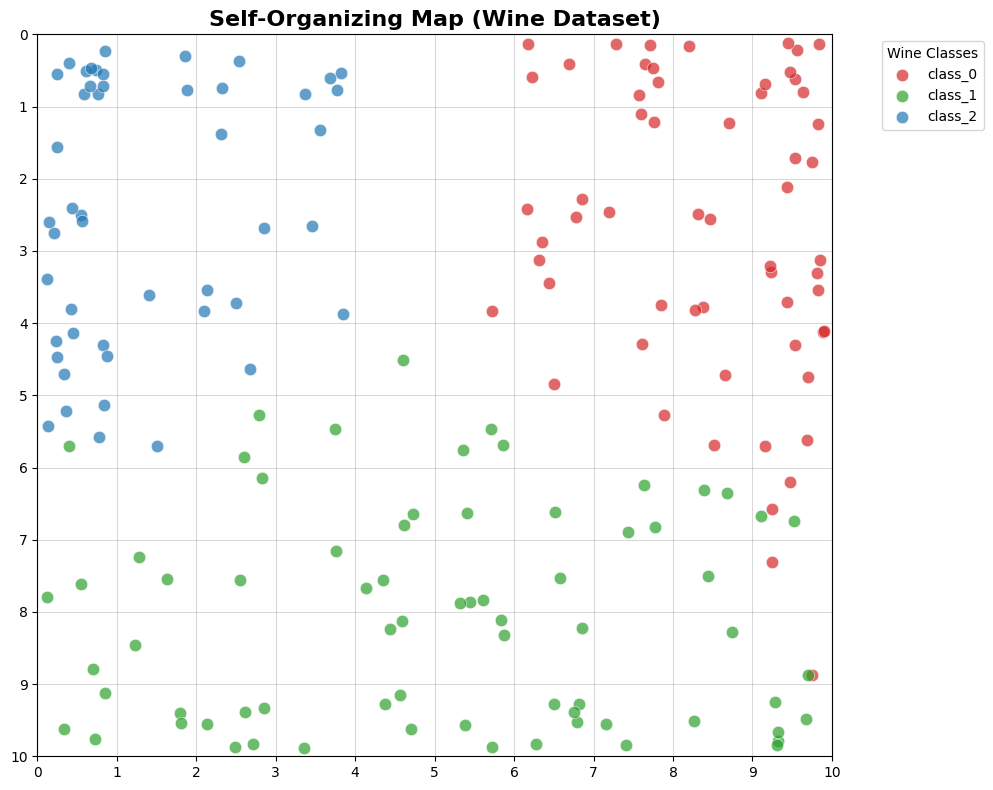

In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine
from sklearn.preprocessing import MinMaxScaler

# ============================================================
# 1. Load and Normalize Dataset
# ============================================================
wine = load_wine()
X = wine.data
y = wine.target

# Normalize data to [0, 1]
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# Convert entire dataset to a tensor once for faster training
X_tensor = tf.convert_to_tensor(X_scaled, dtype=tf.float32)

# ============================================================
# 2. SOM Parameters
# ============================================================
SOM_ROWS = 10
SOM_COLS = 10
INPUT_DIM = X.shape[1]

INITIAL_LEARNING_RATE = 0.5
INITIAL_SIGMA = max(SOM_ROWS, SOM_COLS) / 2.0
EPOCHS = 100

# ============================================================
# 3. Initialize Weights & Grid Coordinates
# ============================================================
# SOM weight matrix: Shape (10, 10, 13)
weights = tf.Variable(tf.random.uniform([SOM_ROWS, SOM_COLS, INPUT_DIM]))

# Pre-compute a grid of coordinates for vectorized distance calculations
x_indices = tf.range(SOM_COLS, dtype=tf.float32)
y_indices = tf.range(SOM_ROWS, dtype=tf.float32)
x_grid, y_grid = tf.meshgrid(x_indices, y_indices)

# Shape: (10, 10, 2) where each element is [y, x]
grid_coords = tf.stack([y_grid, x_grid], axis=-1)

# ============================================================
# 4. Helper Functions
# ============================================================
def find_bmu(sample):
    """Finds the Best Matching Unit (BMU) for a given sample."""
    # Expand sample to broadcast across the weight matrix
    expanded_sample = tf.reshape(sample, (1, 1, INPUT_DIM))

    # Calculate squared Euclidean distance between sample and all weights
    distances = tf.reduce_sum(tf.square(weights - expanded_sample), axis=2)

    # Get the flat index of the minimum distance, then convert to 2D coordinates
    bmu_1d_index = tf.argmin(tf.reshape(distances, [-1]))
    bmu_y = bmu_1d_index // SOM_COLS
    bmu_x = bmu_1d_index % SOM_COLS

    return tf.cast(tf.stack([bmu_y, bmu_x]), tf.float32)

def update_weights_vectorized(sample, bmu_loc, epoch):
    """Updates the entire SOM weight matrix simultaneously."""
    # Calculate decaying learning rate and sigma
    decay_factor = np.exp(-epoch / EPOCHS)
    lr_decay = INITIAL_LEARNING_RATE * decay_factor
    sigma_decay = INITIAL_SIGMA * decay_factor

    # 1. Calculate squared distance of every neuron in the grid to the BMU
    dist_sq_to_bmu = tf.reduce_sum(tf.square(grid_coords - bmu_loc), axis=-1)

    # 2. Calculate the neighborhood influence for every neuron
    neighborhood = tf.exp(-dist_sq_to_bmu / (2 * sigma_decay ** 2))
    influence = neighborhood * lr_decay

    # 3. Expand influence shape to (10, 10, 1) to broadcast against input dimensions
    influence = tf.expand_dims(influence, axis=-1)

    # 4. Update all weights in one vectorized operation
    # new_weight = old_weight + influence * (sample - old_weight)
    weight_update = influence * (sample - weights)
    weights.assign_add(weight_update)

# ============================================================
# 5. Train SOM
# ============================================================
print("Training SOM...")

for epoch in range(EPOCHS):
    # Shuffle dataset each epoch for better generalization (optional but recommended)
    indices = tf.random.shuffle(tf.range(X_tensor.shape[0]))

    for idx in indices:
        sample_tensor = X_tensor[idx]
        bmu_loc = find_bmu(sample_tensor)
        update_weights_vectorized(sample_tensor, bmu_loc, epoch)

    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch + 1}/{EPOCHS}] completed")

print("Training Finished!")

# ============================================================
# 6. Map Data to SOM Grid
# ============================================================
mapped_locations = []

for sample in X_tensor:
    bmu = find_bmu(sample)
    mapped_locations.append(bmu.numpy())

mapped_locations = np.array(mapped_locations)

# ============================================================
# 7. Visualization
# ============================================================
fig, ax = plt.subplots(figsize=(10, 8))

# Colors for the 3 wine classes
colors = ['red', 'green', 'blue'] # Red, Green, Blue
class_names = wine.target_names

# Scatter plot each point slightly jittered so overlapping points are visible
for class_idx in range(len(colors)):
    # Find all samples belonging to the current class
    class_mask = (y == class_idx)
    points = mapped_locations[class_mask]

    # Add random jitter between 0.1 and 0.9 to spread them out within the grid cell
    jitter_y = np.random.rand(len(points)) * 0.8 + 0.1
    jitter_x = np.random.rand(len(points)) * 0.8 + 0.1

    ax.scatter(
        points[:, 1] + jitter_x, # X coordinate
        points[:, 0] + jitter_y, # Y coordinate
        color=colors[class_idx],
        label=class_names[class_idx],
        s=80,
        alpha=0.7,
        edgecolors='white',
        linewidth=0.5
    )

ax.set_title("Self-Organizing Map (Wine Dataset)", fontsize=16, fontweight='bold')
ax.set_xlim([0, SOM_COLS])
ax.set_ylim([0, SOM_ROWS])

# Draw grid lines to clearly show the boundaries of the neurons
ax.set_xticks(np.arange(SOM_COLS + 1))
ax.set_yticks(np.arange(SOM_ROWS + 1))
ax.grid(True, linestyle='-', alpha=0.3, color='gray')

# Invert Y axis so (0,0) is at the top-left (standard matrix representation)
ax.invert_yaxis()

ax.legend(title="Wine Classes", loc="upper right", bbox_to_anchor=(1.2, 1))
plt.tight_layout()
plt.show()